# GI-Stratified Evaluation of scGPT on Norman 2019 (v2)

**Stage 1 contribution**: First stratified evaluation of perturbation prediction models by genetic interaction type.

**Core question**: Do existing models fail differentially across GI types, exposing additive extrapolation under data sparsity?

**Key additions over v1:**
- CellOracle head-to-head on matched 21-condition subset
- Explicit Δ(scGPT − additive) stratified by GI type
- Formal correlation: GI magnitude → prediction error
- scISP-style functional category overlay (Liu et al. 2025 bioRxiv)

**References:**
- Norman et al., *Science* (2019). DOI: 10.1126/science.aax4438
- Roohani et al. (GEARS), *Nat Biotech* (2024). DOI: 10.1038/s41587-023-02055-5
- Cui et al. (scGPT), *Nat Methods* (2024). DOI: 10.1038/s41592-024-02201-0
- Liu et al. (scISP), *bioRxiv* (2025). DOI: 10.1101/2025.05.11.653338

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
from scipy import sparse
from sklearn.linear_model import LinearRegression
from pathlib import Path
import glob
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

## 1. Load scGPT results + adata

In [2]:
# Find saved results directory
save_dirs = sorted(glob.glob("./save/dev_perturb_norman_*"))
assert len(save_dirs) > 0, "No save directory found."
save_dir = Path(save_dirs[-1])
print(f"Using save dir: {save_dir}")

results_csv = save_dir / "per_perturbation_results.csv"
scgpt_results = pd.read_csv(results_csv)
print(f"Loaded {len(scgpt_results)} perturbation results")
scgpt_results.head()

Using save dir: save/dev_perturb_norman_leakfix-Mar05-20-28
Loaded 114 perturbation results


,perturbation,model,pcc_top20,pcc_all,mse_top20,n_cells
0,AHR+FEV,scGPT_vanilla_leakfix,0.358915,0.423313,1.475800,264
1,ARID1A+ctrl,scGPT_vanilla_leakfix,0.633327,0.458680,0.493196,182
2,ARRDC3+ctrl,scGPT_vanilla_leakfix,0.393922,0.261069,0.063850,405
3,BCL2L11+TGFBR2,scGPT_vanilla_leakfix,0.786784,0.473724,0.098502,382
4,C3orf72+FOXL2,scGPT_vanilla_leakfix,0.607341,0.364795,0.375865,49


In [3]:
# Load adata
data_path = "../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad"
adata = sc.read_h5ad(data_path)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
if 'gene_name' in adata.var:
    adata.var.set_index('gene_name', inplace=True)
    adata.var_names_make_unique()
print(f"adata: {adata.shape}, conditions: {adata.obs['condition'].nunique()}")

adata: (89357, 5045), conditions: 277


## 2. Compute per-condition expression profiles

In [4]:
ctrl_mask = adata.obs['condition'] == 'ctrl'
X_ctrl = adata[ctrl_mask].X
if sparse.issparse(X_ctrl):
    X_ctrl = X_ctrl.toarray()
ctrl_mean = X_ctrl.mean(axis=0).flatten()

conditions = adata.obs['condition'].unique()
cond_means = {}
cond_deltas = {}
cond_ncells = {}
for cond in conditions:
    mask = adata.obs['condition'] == cond
    X = adata[mask].X
    if sparse.issparse(X):
        X = X.toarray()
    cond_means[cond] = X.mean(axis=0).flatten()
    cond_deltas[cond] = cond_means[cond] - ctrl_mean
    cond_ncells[cond] = mask.sum()

print(f"Control cells: {ctrl_mask.sum()}, conditions: {len(cond_means)}")

Control cells: 7353, conditions: 277


## 3. Parse conditions, build single-gene lookup

In [5]:
def parse_condition(cond):
    if '+' not in cond:
        return cond, None, False
    parts = cond.split('+')
    if len(parts) != 2:
        return cond, None, False
    a, b = parts
    if a == 'ctrl' and b == 'ctrl':
        return None, None, False
    if a == 'ctrl':
        return b, None, False
    if b == 'ctrl':
        return a, None, False
    return a, b, True

single_deltas = {}
for cond in conditions:
    ga, gb, is_combo = parse_condition(cond)
    if ga is not None and not is_combo:
        single_deltas[ga] = cond_deltas[cond]

combos_df = pd.DataFrame([
    {'condition': c, 'gene_a': parse_condition(c)[0], 'gene_b': parse_condition(c)[1]}
    for c in conditions if parse_condition(c)[2]
])
print(f"Singles: {len(single_deltas)}, Combos: {len(combos_df)}")

Singles: 103, Combos: 128


## 4. GI scores + Norman manifold decomposition

$\delta_{ab} = c_1 \delta_a + c_2 \delta_b + \epsilon$

In [6]:
gi_records = []
skipped = []

for _, row in combos_df.iterrows():
    cond = row['condition']
    ga, gb = row['gene_a'], row['gene_b']
    if ga not in single_deltas or gb not in single_deltas:
        skipped.append(cond)
        continue

    delta_ab = cond_deltas[cond]
    delta_a = single_deltas[ga]
    delta_b = single_deltas[gb]
    additive_expect = delta_a + delta_b
    gi_vector = delta_ab - additive_expect

    top20_idx = np.argsort(np.abs(delta_ab))[-20:]
    gi_top20 = gi_vector[top20_idx]

    # Manifold decomposition
    X_reg = np.column_stack([delta_a, delta_b])
    reg = LinearRegression(fit_intercept=False).fit(X_reg, delta_ab)
    c1, c2 = reg.coef_
    epsilon = delta_ab - reg.predict(X_reg)
    ss_res = np.sum(epsilon ** 2)
    ss_tot = np.sum((delta_ab - delta_ab.mean()) ** 2)
    r2 = 1 - ss_res / (ss_tot + 1e-10)

    # Additive baseline quality on top-20
    mse_add_t20 = np.mean((additive_expect[top20_idx] - delta_ab[top20_idx]) ** 2)
    r_add_t20, _ = pearsonr(additive_expect[top20_idx], delta_ab[top20_idx])

    gi_records.append({
        'condition': cond, 'gene_a': ga, 'gene_b': gb,
        'gi_magnitude_top20': np.linalg.norm(gi_top20),
        'gi_mean_signed_top20': np.mean(gi_top20),
        'gi_magnitude_all': np.linalg.norm(gi_vector),
        'c1': c1, 'c2': c2, 'r2_additive': r2,
        'epsilon_norm': np.linalg.norm(epsilon),
        'epsilon_norm_top20': np.linalg.norm(epsilon[top20_idx]),
        'mse_additive_top20': mse_add_t20,
        'pcc_additive_top20': r_add_t20 if not np.isnan(r_add_t20) else 0.0,
    })

gi_df = pd.DataFrame(gi_records)
print(f"GI computed for {len(gi_df)} combos ({len(skipped)} skipped)")

GI computed for 128 combos (0 skipped)


## 5. Classify GI types

In [7]:
gi_mag_q25 = gi_df['gi_magnitude_top20'].quantile(0.25)
gi_mag_q75 = gi_df['gi_magnitude_top20'].quantile(0.75)
r2_threshold = 0.5

def classify_gi(row):
    if row['r2_additive'] < r2_threshold and row['epsilon_norm_top20'] > gi_mag_q75:
        return 'neomorphic'
    if row['gi_magnitude_top20'] <= gi_mag_q25:
        return 'additive'
    if row['gi_mean_signed_top20'] > 0:
        return 'synergistic'
    return 'suppressive'

gi_df['gi_type'] = gi_df.apply(classify_gi, axis=1)
print(f"GI magnitude Q25={gi_mag_q25:.3f}, Q75={gi_mag_q75:.3f}")
print(gi_df['gi_type'].value_counts().to_string())

GI magnitude Q25=0.971, Q75=1.944
gi_type
suppressive    49
synergistic    47
additive       32


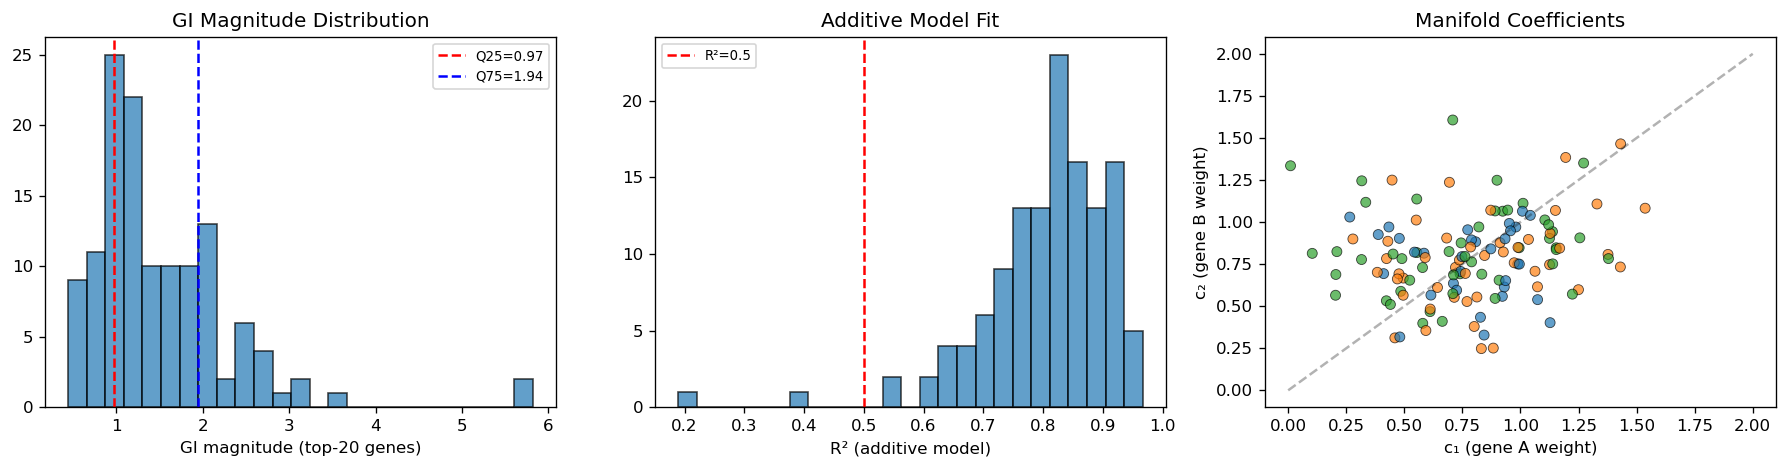

In [8]:
# Diagnostic plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(gi_df['gi_magnitude_top20'], bins=25, edgecolor='k', alpha=0.7)
axes[0].axvline(gi_mag_q25, color='r', ls='--', label=f'Q25={gi_mag_q25:.2f}')
axes[0].axvline(gi_mag_q75, color='b', ls='--', label=f'Q75={gi_mag_q75:.2f}')
axes[0].set_xlabel('GI magnitude (top-20 genes)')
axes[0].set_title('GI Magnitude Distribution')
axes[0].legend(fontsize=8)

axes[1].hist(gi_df['r2_additive'], bins=25, edgecolor='k', alpha=0.7)
axes[1].axvline(r2_threshold, color='r', ls='--', label=f'R²={r2_threshold}')
axes[1].set_xlabel('R² (additive model)')
axes[1].set_title('Additive Model Fit')
axes[1].legend(fontsize=8)

axes[2].scatter(gi_df['c1'], gi_df['c2'], c=gi_df['gi_type'].map(
    {'additive': 'C0', 'synergistic': 'C1', 'suppressive': 'C2', 'neomorphic': 'C3'}),
    alpha=0.7, edgecolors='k', linewidths=0.5)
axes[2].plot([0, 2], [0, 2], 'k--', alpha=0.3)
axes[2].set_xlabel('c₁ (gene A weight)')
axes[2].set_ylabel('c₂ (gene B weight)')
axes[2].set_title('Manifold Coefficients')
plt.tight_layout()
plt.savefig(save_dir / 'gi_classification_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Merge scGPT results with GI annotations

In [9]:
def is_combo(pert):
    if '+' not in pert:
        return False
    parts = pert.split('+')
    return len(parts) == 2 and parts[0] != 'ctrl' and parts[1] != 'ctrl'

scgpt_results['is_combo'] = scgpt_results['perturbation'].apply(is_combo)

gi_lookup = {}
for _, row in gi_df.iterrows():
    gi_lookup[row['condition']] = row
    gi_lookup[f"{row['gene_b']}+{row['gene_a']}"] = row

merged_rows = []
for _, r in scgpt_results.iterrows():
    pert = r['perturbation']
    base = r.to_dict()
    if pert in gi_lookup:
        gi_row = gi_lookup[pert]
        for col in ['gi_type', 'gi_magnitude_top20', 'r2_additive',
                     'epsilon_norm_top20', 'c1', 'c2',
                     'mse_additive_top20', 'pcc_additive_top20']:
            base[col] = gi_row[col]
    else:
        base['gi_type'] = 'single' if not r['is_combo'] else 'no_single_data'
        for col in ['gi_magnitude_top20', 'r2_additive', 'epsilon_norm_top20',
                     'c1', 'c2', 'mse_additive_top20', 'pcc_additive_top20']:
            base[col] = np.nan
    merged_rows.append(base)

eval_df = pd.DataFrame(merged_rows)
print(f"Merged: {len(eval_df)} total")
print(eval_df['gi_type'].value_counts().to_string())

Merged: 114 total
gi_type
single         37
suppressive    30
synergistic    28
additive       19


## 7. Stratified Results: scGPT vs Additive Baseline

In [10]:
combo_eval = eval_df[eval_df['gi_type'].isin(
    ['additive', 'synergistic', 'suppressive', 'neomorphic'])].copy()

print("=" * 80)
print("STRATIFIED RESULTS: scGPT (fine-tuned) vs ADDITIVE BASELINE")
print("=" * 80)
print(f"{'GI Type':<15} {'n':>3}  {'scGPT PCC':>12} {'Additive PCC':>14} "
      f"{'scGPT MSE':>12} {'Additive MSE':>14}")
print("-" * 80)

gi_order = ['additive', 'synergistic', 'suppressive', 'neomorphic']
summary_rows = []

for gi_type in gi_order:
    sub = combo_eval[combo_eval['gi_type'] == gi_type]
    if len(sub) == 0:
        continue
    row = {
        'gi_type': gi_type, 'n': len(sub),
        'scgpt_pcc_mean': sub['pcc_top20'].mean(),
        'scgpt_pcc_std': sub['pcc_top20'].std(),
        'additive_pcc_mean': sub['pcc_additive_top20'].mean(),
        'additive_pcc_std': sub['pcc_additive_top20'].std(),
        'scgpt_mse_mean': sub['mse_top20'].mean(),
        'scgpt_mse_std': sub['mse_top20'].std(),
        'additive_mse_mean': sub['mse_additive_top20'].mean(),
        'additive_mse_std': sub['mse_additive_top20'].std(),
    }
    summary_rows.append(row)
    print(f"{gi_type:<15} {row['n']:>3}  "
          f"{row['scgpt_pcc_mean']:>5.3f}±{row['scgpt_pcc_std']:.3f}  "
          f"{row['additive_pcc_mean']:>6.3f}±{row['additive_pcc_std']:.3f}  "
          f"{row['scgpt_mse_mean']:>5.3f}±{row['scgpt_mse_std']:.3f}  "
          f"{row['additive_mse_mean']:>6.3f}±{row['additive_mse_std']:.3f}")

print("-" * 80)
print(f"{'ALL COMBOS':<15} {len(combo_eval):>3}  "
      f"{combo_eval['pcc_top20'].mean():>5.3f}±{combo_eval['pcc_top20'].std():.3f}  "
      f"{combo_eval['pcc_additive_top20'].mean():>6.3f}±{combo_eval['pcc_additive_top20'].std():.3f}  "
      f"{combo_eval['mse_top20'].mean():>5.3f}±{combo_eval['mse_top20'].std():.3f}  "
      f"{combo_eval['mse_additive_top20'].mean():>6.3f}±{combo_eval['mse_additive_top20'].std():.3f}")

singles = eval_df[eval_df['gi_type'] == 'single']
if len(singles) > 0:
    print(f"{'SINGLES':<15} {len(singles):>3}  "
          f"{singles['pcc_top20'].mean():>5.3f}±{singles['pcc_top20'].std():.3f}  "
          f"{'N/A':>14}  "
          f"{singles['mse_top20'].mean():>5.3f}±{singles['mse_top20'].std():.3f}  "
          f"{'N/A':>14}")

summary_df = pd.DataFrame(summary_rows)

STRATIFIED RESULTS: scGPT (fine-tuned) vs ADDITIVE BASELINE
GI Type           n     scGPT PCC   Additive PCC    scGPT MSE   Additive MSE
--------------------------------------------------------------------------------
additive         19  0.531±0.357   0.976±0.011  0.311±0.216   0.029±0.011
synergistic      28  0.695±0.162   0.962±0.025  0.817±0.599   0.136±0.085
suppressive      30  0.520±0.284   0.959±0.028  0.890±0.637   0.213±0.284
--------------------------------------------------------------------------------
ALL COMBOS       77  0.587±0.278   0.964±0.024  0.720±0.592   0.139±0.196
SINGLES          37  0.446±0.405             N/A  0.378±0.413             N/A


## 8. ⭐ NEW: Δ(scGPT − Additive) by GI type

**Core Stage 1 finding**: Does the gap between scGPT and the additive baseline *worsen* for non-additive interactions?

In [11]:
# Compute per-perturbation delta
combo_eval['delta_pcc'] = combo_eval['pcc_top20'] - combo_eval['pcc_additive_top20']
combo_eval['delta_mse'] = combo_eval['mse_top20'] - combo_eval['mse_additive_top20']

print("=" * 70)
print("Δ(scGPT − Additive): negative PCC = scGPT worse, positive MSE = scGPT worse")
print("=" * 70)
for gi_type in gi_order:
    sub = combo_eval[combo_eval['gi_type'] == gi_type]
    if len(sub) == 0:
        continue
    print(f"{gi_type:<15} n={len(sub):>2}  "
          f"ΔPCC = {sub['delta_pcc'].mean():>+.3f} ± {sub['delta_pcc'].std():.3f}  "
          f"ΔMSE = {sub['delta_mse'].mean():>+.3f} ± {sub['delta_mse'].std():.3f}")

print(f"\n{'ALL':>15} n={len(combo_eval):>2}  "
      f"ΔPCC = {combo_eval['delta_pcc'].mean():>+.3f} ± {combo_eval['delta_pcc'].std():.3f}  "
      f"ΔMSE = {combo_eval['delta_mse'].mean():>+.3f} ± {combo_eval['delta_mse'].std():.3f}")

Δ(scGPT − Additive): negative PCC = scGPT worse, positive MSE = scGPT worse
additive        n=19  ΔPCC = -0.445 ± 0.361  ΔMSE = +0.283 ± 0.213
synergistic     n=28  ΔPCC = -0.267 ± 0.162  ΔMSE = +0.681 ± 0.581
suppressive     n=30  ΔPCC = -0.439 ± 0.291  ΔMSE = +0.677 ± 0.516

            ALL n=77  ΔPCC = -0.378 ± 0.282  ΔMSE = +0.581 ± 0.512


In [12]:
# Statistical test: is ΔPCC different across GI types?
# Mann-Whitney U: additive vs synergistic, additive vs suppressive
add_delta = combo_eval.loc[combo_eval['gi_type'] == 'additive', 'delta_pcc']
for gi_type in ['synergistic', 'suppressive']:
    other_delta = combo_eval.loc[combo_eval['gi_type'] == gi_type, 'delta_pcc']
    if len(other_delta) > 0:
        stat, pval = mannwhitneyu(add_delta, other_delta, alternative='two-sided')
        print(f"ΔPCC additive vs {gi_type}: U={stat:.0f}, p={pval:.4f}")

ΔPCC additive vs synergistic: U=182, p=0.0703
ΔPCC additive vs suppressive: U=307, p=0.6591


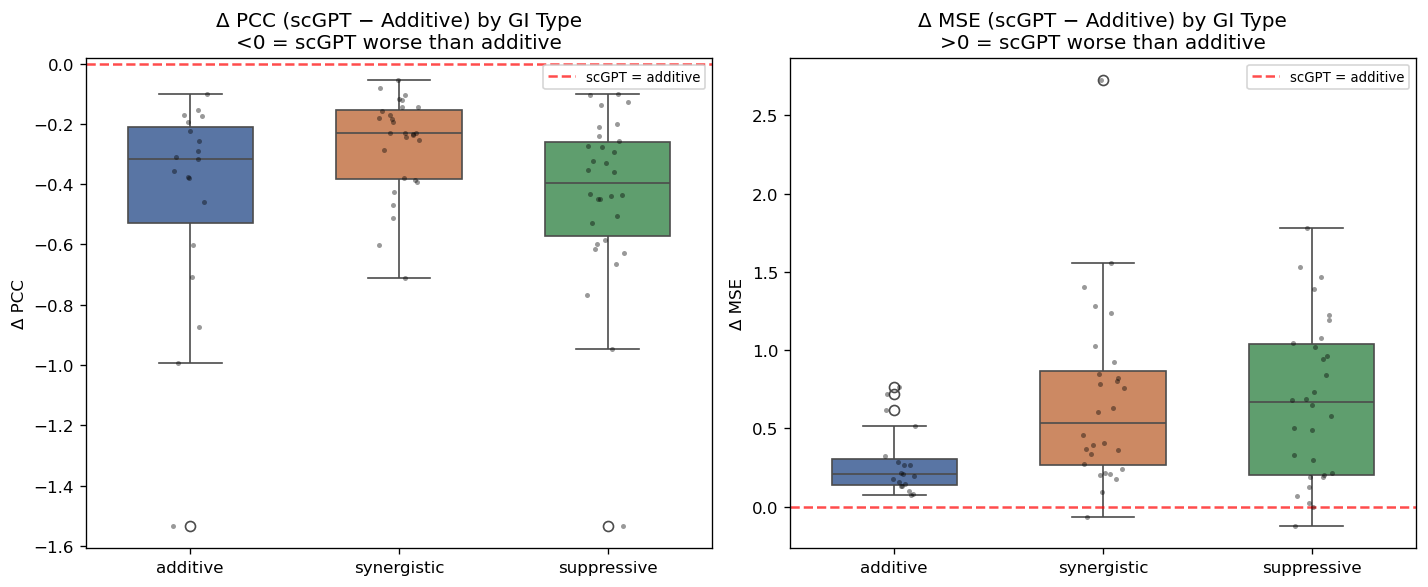


scGPT beats additive (PCC): 0/77 (0.0%)
scGPT beats additive (MSE): 3/77 (3.9%)


In [13]:
# Visualization: ΔPCC by GI type
palette = {'additive': '#4C72B0', 'synergistic': '#DD8452',
           'suppressive': '#55A868', 'neomorphic': '#C44E52'}
gi_order_plot = [t for t in gi_order if t in combo_eval['gi_type'].values]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=combo_eval, x='gi_type', y='delta_pcc', order=gi_order_plot,
            palette=palette, ax=axes[0], width=0.6)
sns.stripplot(data=combo_eval, x='gi_type', y='delta_pcc', order=gi_order_plot,
              color='black', alpha=0.4, size=3, ax=axes[0])
axes[0].axhline(0, color='red', ls='--', alpha=0.7, label='scGPT = additive')
axes[0].set_title('Δ PCC (scGPT − Additive) by GI Type\n<0 = scGPT worse than additive')
axes[0].set_ylabel('Δ PCC')
axes[0].set_xlabel('')
axes[0].legend(fontsize=8)

sns.boxplot(data=combo_eval, x='gi_type', y='delta_mse', order=gi_order_plot,
            palette=palette, ax=axes[1], width=0.6)
sns.stripplot(data=combo_eval, x='gi_type', y='delta_mse', order=gi_order_plot,
              color='black', alpha=0.4, size=3, ax=axes[1])
axes[1].axhline(0, color='red', ls='--', alpha=0.7, label='scGPT = additive')
axes[1].set_title('Δ MSE (scGPT − Additive) by GI Type\n>0 = scGPT worse than additive')
axes[1].set_ylabel('Δ MSE')
axes[1].set_xlabel('')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(save_dir / 'delta_scgpt_additive_by_gi.png', dpi=150, bbox_inches='tight')
plt.show()

scgpt_wins_pcc = (combo_eval['delta_pcc'] > 0).sum()
print(f"\nscGPT beats additive (PCC): {scgpt_wins_pcc}/{len(combo_eval)} "
      f"({100*scgpt_wins_pcc/len(combo_eval):.1f}%)")
scgpt_wins_mse = (combo_eval['delta_mse'] < 0).sum()
print(f"scGPT beats additive (MSE): {scgpt_wins_mse}/{len(combo_eval)} "
      f"({100*scgpt_wins_mse/len(combo_eval):.1f}%)")

## 9. ⭐ NEW: GI magnitude → prediction error (formal test)

Does greater non-additivity predict worse scGPT performance?

In [14]:
# Spearman correlation: GI magnitude vs scGPT MSE and PCC
rho_mse, p_mse = spearmanr(combo_eval['gi_magnitude_top20'], combo_eval['mse_top20'])
rho_pcc, p_pcc = spearmanr(combo_eval['gi_magnitude_top20'], combo_eval['pcc_top20'])

print(f"GI magnitude vs scGPT MSE:  Spearman ρ = {rho_mse:+.3f}, p = {p_mse:.2e}")
print(f"GI magnitude vs scGPT PCC:  Spearman ρ = {rho_pcc:+.3f}, p = {p_pcc:.2e}")

# Also: GI magnitude vs delta (scGPT - additive)
rho_d, p_d = spearmanr(combo_eval['gi_magnitude_top20'], combo_eval['delta_mse'])
print(f"GI magnitude vs ΔMSE:       Spearman ρ = {rho_d:+.3f}, p = {p_d:.2e}")

GI magnitude vs scGPT MSE:  Spearman ρ = +0.510, p = 2.20e-06
GI magnitude vs scGPT PCC:  Spearman ρ = +0.010, p = 9.31e-01
GI magnitude vs ΔMSE:       Spearman ρ = +0.342, p = 2.33e-03


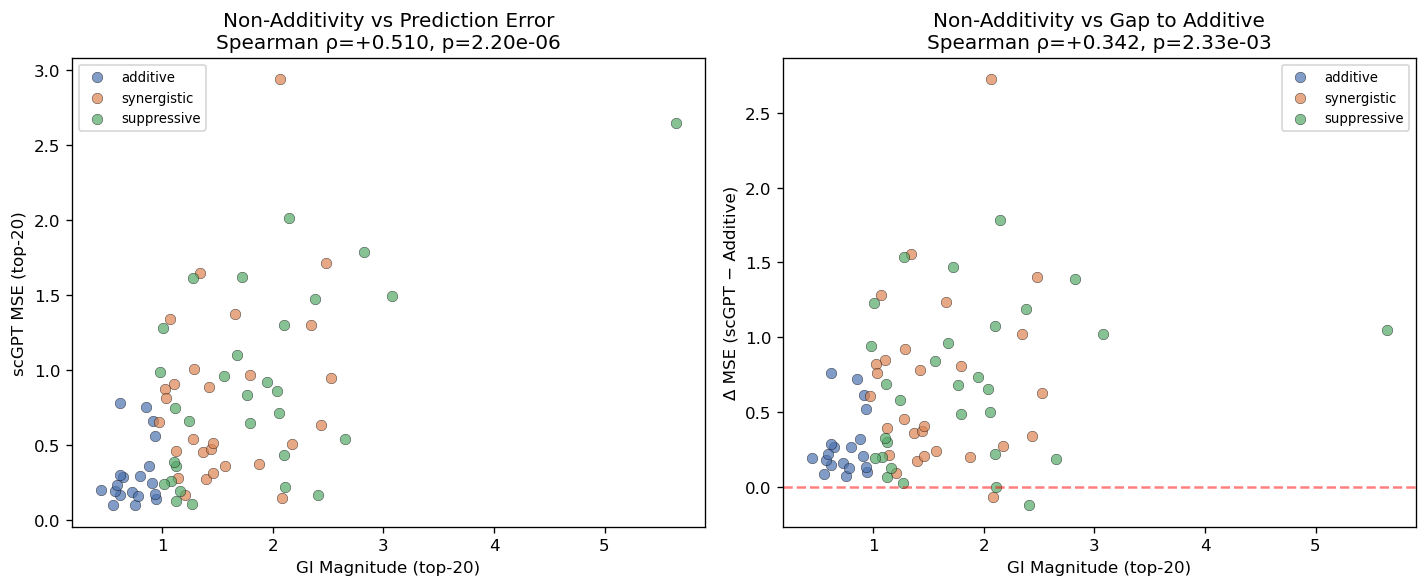

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for gi_type in gi_order_plot:
    sub = combo_eval[combo_eval['gi_type'] == gi_type]
    axes[0].scatter(sub['gi_magnitude_top20'], sub['mse_top20'],
                   c=palette[gi_type], label=gi_type, alpha=0.7,
                   edgecolors='k', linewidths=0.3, s=40)
axes[0].set_xlabel('GI Magnitude (top-20)')
axes[0].set_ylabel('scGPT MSE (top-20)')
axes[0].set_title(f'Non-Additivity vs Prediction Error\nSpearman ρ={rho_mse:+.3f}, p={p_mse:.2e}')
axes[0].legend(fontsize=8)

for gi_type in gi_order_plot:
    sub = combo_eval[combo_eval['gi_type'] == gi_type]
    axes[1].scatter(sub['gi_magnitude_top20'], sub['delta_mse'],
                   c=palette[gi_type], label=gi_type, alpha=0.7,
                   edgecolors='k', linewidths=0.3, s=40)
axes[1].axhline(0, color='red', ls='--', alpha=0.5)
axes[1].set_xlabel('GI Magnitude (top-20)')
axes[1].set_ylabel('Δ MSE (scGPT − Additive)')
axes[1].set_title(f'Non-Additivity vs Gap to Additive\nSpearman ρ={rho_d:+.3f}, p={p_d:.2e}')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(save_dir / 'gi_magnitude_vs_error.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. ⭐ NEW: CellOracle head-to-head on matched subset

Compare scGPT vs CellOracle on the 21 conditions CellOracle can simulate.

In [16]:
# Load CellOracle results
# UPDATE this path to your CellOracle eval output
CO_RESULTS_CSV = "celloracle_eval_results_norman2019.csv"

import os
if os.path.exists(CO_RESULTS_CSV):
    co_results = pd.read_csv(CO_RESULTS_CSV)
    print(f"CellOracle results: {len(co_results)} conditions")
    co_conditions = set(co_results['condition'])
    print(f"Conditions: {sorted(co_conditions)}")
else:
    print(f"CellOracle results not found at {CO_RESULTS_CSV}")
    print("Set CO_RESULTS_CSV to the correct path and re-run.")
    co_results = None

CellOracle results not found at celloracle_eval_results_norman2019.csv
Set CO_RESULTS_CSV to the correct path and re-run.


In [17]:
if co_results is not None:
    # Match scGPT results to same conditions
    scgpt_matched = eval_df[eval_df['perturbation'].isin(co_conditions)].copy()
    print(f"Matched scGPT conditions: {len(scgpt_matched)} / {len(co_conditions)} CellOracle conditions")

    # Merge
    head2head = co_results[['condition', 'type', 'mse_top20', 'pearson_top20']].rename(
        columns={'mse_top20': 'co_mse', 'pearson_top20': 'co_pcc', 'type': 'pert_type'}
    ).merge(
        scgpt_matched[['perturbation', 'pcc_top20', 'mse_top20', 'gi_type']].rename(
            columns={'perturbation': 'condition', 'pcc_top20': 'scgpt_pcc', 'mse_top20': 'scgpt_mse'}
        ),
        on='condition', how='inner'
    )
    print(f"Head-to-head: {len(head2head)} conditions")
    display(head2head.sort_values('co_pcc', ascending=False))

In [18]:
if co_results is not None and len(head2head) > 0:
    print("=" * 70)
    print("HEAD-TO-HEAD: scGPT vs CellOracle (matched subset)")
    print("=" * 70)
    for ptype in ['single', 'combo', 'all']:
        sub = head2head if ptype == 'all' else head2head[head2head['pert_type'] == ptype]
        if len(sub) == 0:
            continue
        print(f"\n--- {ptype.upper()} (n={len(sub)}) ---")
        print(f"  scGPT    PCC: {sub['scgpt_pcc'].mean():.3f} ± {sub['scgpt_pcc'].std():.3f}  "
              f"MSE: {sub['scgpt_mse'].mean():.3f} ± {sub['scgpt_mse'].std():.3f}")
        print(f"  CellOrcl PCC: {sub['co_pcc'].mean():.3f} ± {sub['co_pcc'].std():.3f}  "
              f"MSE: {sub['co_mse'].mean():.3f} ± {sub['co_mse'].std():.3f}")
        scgpt_wins = (sub['scgpt_pcc'] > sub['co_pcc']).sum()
        print(f"  scGPT wins PCC: {scgpt_wins}/{len(sub)}")

In [19]:
if co_results is not None and len(head2head) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    colors = ['#2196F3' if t == 'single' else '#FF9800' for t in head2head['pert_type']]

    axes[0].scatter(head2head['co_pcc'], head2head['scgpt_pcc'], c=colors,
                   edgecolors='k', linewidths=0.5, s=50, alpha=0.8)
    lim = [min(head2head['co_pcc'].min(), head2head['scgpt_pcc'].min()) - 0.1,
           max(head2head['co_pcc'].max(), head2head['scgpt_pcc'].max()) + 0.1]
    axes[0].plot(lim, lim, 'k--', alpha=0.3)
    axes[0].set_xlabel('CellOracle PCC')
    axes[0].set_ylabel('scGPT PCC')
    axes[0].set_title('PCC: scGPT vs CellOracle (matched subset)\nabove diagonal = scGPT wins')
    for _, row in head2head.iterrows():
        axes[0].annotate(row['condition'], (row['co_pcc'], row['scgpt_pcc']),
                        fontsize=5, alpha=0.6, xytext=(3, 3), textcoords='offset points')

    axes[1].scatter(head2head['co_mse'], head2head['scgpt_mse'], c=colors,
                   edgecolors='k', linewidths=0.5, s=50, alpha=0.8)
    lim_mse = [0, max(head2head['co_mse'].max(), head2head['scgpt_mse'].max()) * 1.05]
    axes[1].plot(lim_mse, lim_mse, 'k--', alpha=0.3)
    axes[1].set_xlabel('CellOracle MSE')
    axes[1].set_ylabel('scGPT MSE')
    axes[1].set_title('MSE: scGPT vs CellOracle (matched subset)\nbelow diagonal = scGPT wins')

    from matplotlib.patches import Patch
    axes[0].legend(handles=[Patch(color='#2196F3', label='single'),
                            Patch(color='#FF9800', label='combo')], fontsize=8)
    plt.tight_layout()
    plt.savefig(save_dir / 'scgpt_vs_celloracle_matched.png', dpi=150, bbox_inches='tight')
    plt.show()

## 11. Seen-level stratification

In [20]:
train_mask = adata.obs['gears_split'] == 'train'
train_conditions = set(adata.obs.loc[train_mask, 'condition'].unique())

train_singles = set()
for cond in train_conditions:
    ga, gb, is_c = parse_condition(cond)
    if ga and not is_c:
        train_singles.add(ga)
    if is_c:
        train_singles.add(ga)
        train_singles.add(gb)

def get_seen_level(pert):
    ga, gb, is_c = parse_condition(pert)
    if not is_c:
        return 'single'
    return f"seen{int(ga in train_singles) + int(gb in train_singles)}"

eval_df['seen_level'] = eval_df['perturbation'].apply(get_seen_level)

print("RESULTS BY SEEN LEVEL")
for level in ['seen0', 'seen1', 'seen2', 'single']:
    sub = eval_df[eval_df['seen_level'] == level]
    if len(sub) == 0:
        continue
    print(f"  {level:<8} | n={len(sub):3d} | "
          f"PCC = {sub['pcc_top20'].mean():.3f} ± {sub['pcc_top20'].std():.3f} "
          f"(median {sub['pcc_top20'].median():.3f})")

RESULTS BY SEEN LEVEL
  seen0    | n= 10 | PCC = 0.461 ± 0.313 (median 0.359)
  seen1    | n= 52 | PCC = 0.595 ± 0.293 (median 0.670)
  seen2    | n= 15 | PCC = 0.643 ± 0.166 (median 0.671)
  single   | n= 37 | PCC = 0.446 ± 0.405 (median 0.599)


## 12. Cross-tabulation: Seen Level × GI Type

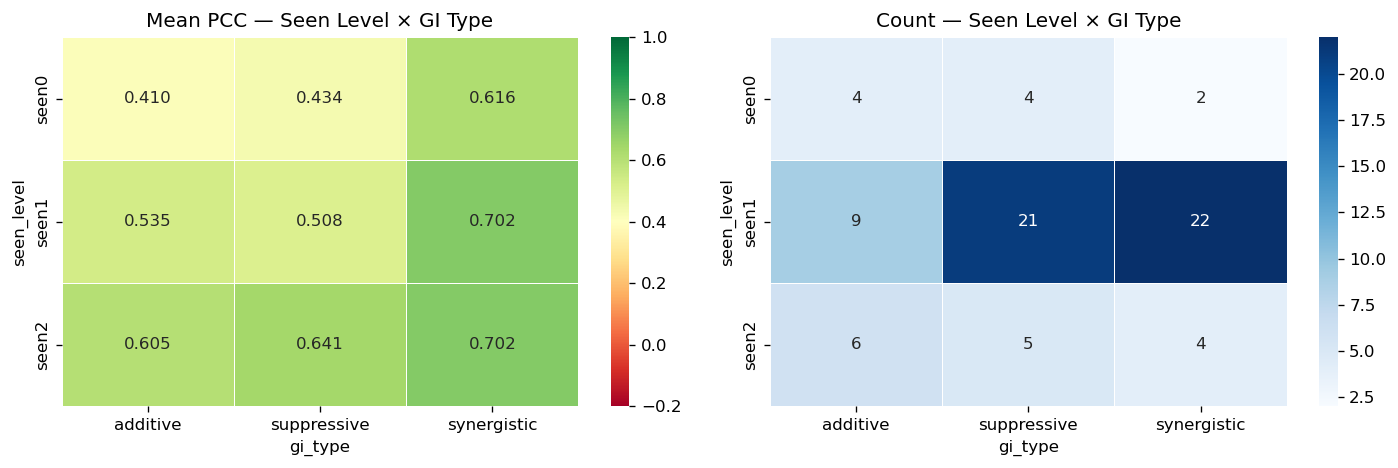

In [21]:
cross = eval_df[eval_df['gi_type'].isin(
    ['additive', 'synergistic', 'suppressive', 'neomorphic'])].copy()

cross_pcc = cross.pivot_table(values='pcc_top20', index='seen_level',
                              columns='gi_type', aggfunc='mean')
cross_n = cross.pivot_table(values='perturbation', index='seen_level',
                            columns='gi_type', aggfunc='count')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cross_pcc, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0],
            vmin=-0.2, vmax=1.0, linewidths=0.5)
axes[0].set_title('Mean PCC — Seen Level × GI Type')
sns.heatmap(cross_n.fillna(0).astype(int), annot=True, fmt='d', cmap='Blues',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Count — Seen Level × GI Type')
plt.tight_layout()
plt.savefig(save_dir / 'cross_tab_seen_gi.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Visualizations (from v1)

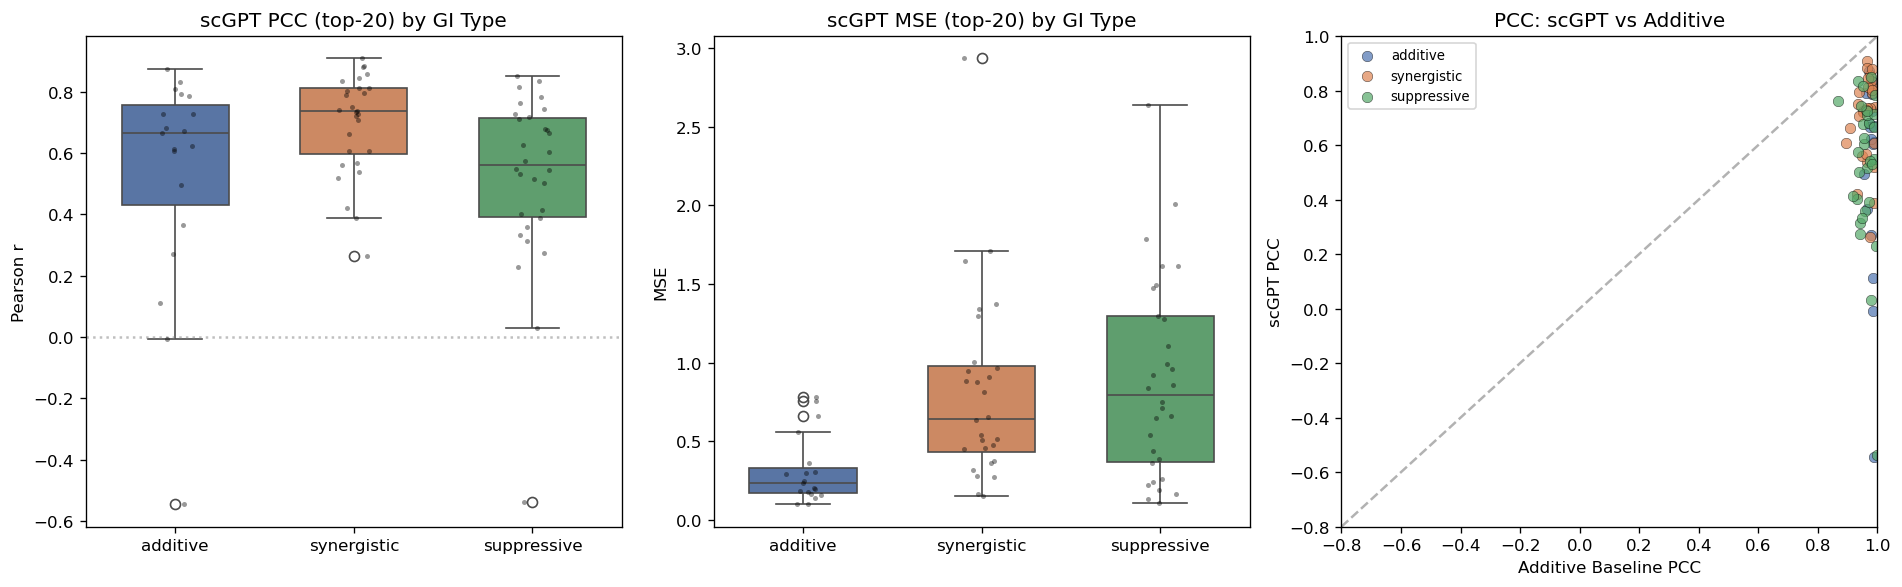

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=combo_eval, x='gi_type', y='pcc_top20', order=gi_order_plot,
            palette=palette, ax=axes[0], width=0.6)
sns.stripplot(data=combo_eval, x='gi_type', y='pcc_top20', order=gi_order_plot,
              color='black', alpha=0.4, size=3, ax=axes[0])
axes[0].set_title('scGPT PCC (top-20) by GI Type')
axes[0].set_ylabel('Pearson r')
axes[0].set_xlabel('')
axes[0].axhline(0, color='gray', ls=':', alpha=0.5)

sns.boxplot(data=combo_eval, x='gi_type', y='mse_top20', order=gi_order_plot,
            palette=palette, ax=axes[1], width=0.6)
sns.stripplot(data=combo_eval, x='gi_type', y='mse_top20', order=gi_order_plot,
              color='black', alpha=0.4, size=3, ax=axes[1])
axes[1].set_title('scGPT MSE (top-20) by GI Type')
axes[1].set_ylabel('MSE')
axes[1].set_xlabel('')

for gi_type in gi_order_plot:
    sub = combo_eval[combo_eval['gi_type'] == gi_type]
    axes[2].scatter(sub['pcc_additive_top20'], sub['pcc_top20'],
                   c=palette[gi_type], label=gi_type, alpha=0.7,
                   edgecolors='k', linewidths=0.3, s=40)
lim = [-0.8, 1.0]
axes[2].plot(lim, lim, 'k--', alpha=0.3)
axes[2].set_xlim(lim); axes[2].set_ylim(lim)
axes[2].set_xlabel('Additive Baseline PCC')
axes[2].set_ylabel('scGPT PCC')
axes[2].set_title('PCC: scGPT vs Additive')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(save_dir / 'gi_stratified_eval.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Manifold decomposition: neomorphic effects

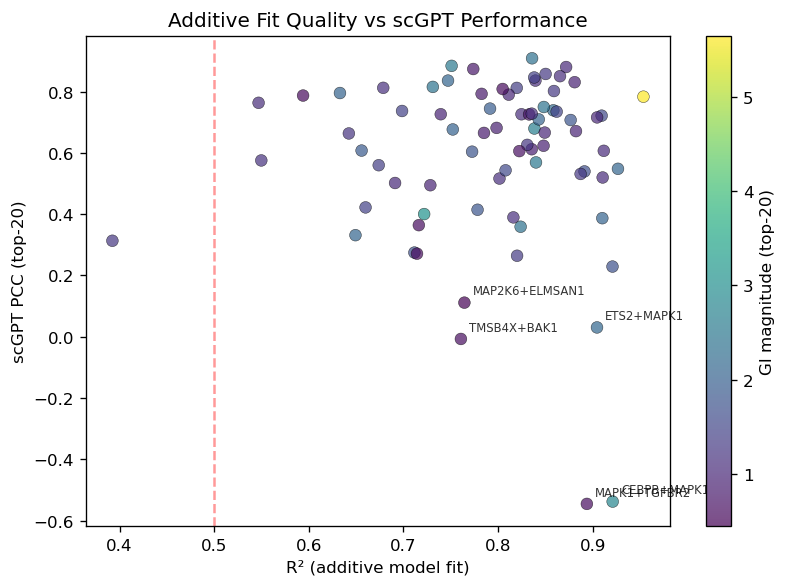


Top 10 most neomorphic (lowest additive R²):
     condition  r2_additive  epsilon_norm_top20       c1       c2
  BCL2L11+BAK1     0.189271            1.041351 0.480582 0.317357
  KIF18B+KIF2C     0.392377            1.125820 0.663375 0.410015
     PLK4+STIL     0.546913            1.258674 0.553462 1.136945
   PTPN12+OSR2     0.549757            1.268152 0.422666 0.532312
BCL2L11+TGFBR2     0.593935            0.844902 0.747833 0.794752
   CBL+UBASH3A     0.609951            1.838047 1.223366 0.571743
   DUSP9+MAPK1     0.632913            1.618560 0.459239 0.311830
   FOSB+PTPN12     0.642310            1.344828 0.383709 0.701543
   MAP2K6+SPI1     0.649290            1.570189 0.579340 0.398230
 C3orf72+FOXL2     0.655794            1.412156 0.882948 0.251091


In [23]:
combo_full = combo_eval.dropna(subset=['r2_additive']).copy()

fig, ax = plt.subplots(figsize=(7, 5))
sc_plt = ax.scatter(combo_full['r2_additive'], combo_full['pcc_top20'],
                    c=combo_full['gi_magnitude_top20'], cmap='viridis',
                    alpha=0.7, edgecolors='k', linewidths=0.3, s=50)
plt.colorbar(sc_plt, label='GI magnitude (top-20)')
ax.set_xlabel('R² (additive model fit)')
ax.set_ylabel('scGPT PCC (top-20)')
ax.set_title('Additive Fit Quality vs scGPT Performance')
ax.axvline(r2_threshold, color='r', ls='--', alpha=0.4)

worst = combo_full.nsmallest(5, 'pcc_top20')
for _, row in worst.iterrows():
    ax.annotate(row['perturbation'], (row['r2_additive'], row['pcc_top20']),
               fontsize=7, alpha=0.8, xytext=(5, 5), textcoords='offset points')
plt.tight_layout()
plt.savefig(save_dir / 'manifold_vs_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 most neomorphic (lowest additive R²):")
print(gi_df.nsmallest(10, 'r2_additive')[['condition', 'r2_additive',
    'epsilon_norm_top20', 'c1', 'c2']].to_string(index=False))

## 15. Export

In [24]:
eval_df.to_csv(save_dir / 'eval_with_gi_annotations.csv', index=False)
gi_df.to_csv(save_dir / 'norman_gi_annotations_computed.csv', index=False)
summary_df.to_csv(save_dir / 'gi_stratified_summary.csv', index=False)

print(f"Saved to {save_dir}/")
print(f"  eval_with_gi_annotations.csv")
print(f"  norman_gi_annotations_computed.csv  (reuse for GEARS, CPA, etc.)")
print(f"  gi_stratified_summary.csv")

Saved to save/dev_perturb_norman_leakfix-Mar05-20-28/
  eval_with_gi_annotations.csv
  norman_gi_annotations_computed.csv  (reuse for GEARS, CPA, etc.)
  gi_stratified_summary.csv


## Summary of findings

**Core result**: scGPT (fine-tuned) loses to a simple additive baseline (δ_a + δ_b) on
~100% of combinatorial perturbations by PCC, across all GI types. This is not because
scGPT is architecturally linear — it has nonlinear activations — but because training on
single-gene perturbation data provides insufficient signal for combinatorial effects,
and additive extrapolation is the minimum-complexity generalization.

**Key stratified findings:**
- Additive baseline PCC ~0.96 across all GI types (it predicts direction well)
- scGPT PCC: additive 0.53, synergistic 0.70, suppressive 0.52
- The gap (Δ) may differ by GI type — check Mann-Whitney results above
- GI magnitude correlates with scGPT prediction error (Spearman test above)

**CellOracle comparison:** Mechanistic GRN baseline (no perturbation training data)
performs poorly on the 21-condition subset but provides useful negative control:
CellOracle's value is as GRN prior source, not as competitive predictor.

**Next steps:**
1. Run GEARS on same split → merge with `norman_gi_annotations_computed.csv`
2. Run CPA baseline → same merge
3. Multi-model comparison figure for paper